# INNM_FPM —— 原 `INNM.ipynb` 的 TensorFlow 2.x 迁移版

本文件由 `INNM.ipynb`（TF 1.x + 多后端 Keras 2）迁移而来，**算法与网络结构完全一致**，只替换了已被删除的 API。

所有与原代码不同的地方都用 `# [MIGRATED]` 注释标出，注释里写明了原代码是什么、为什么要改。

## 运行环境

```
python >= 3.9
tensorflow 2.10 ~ 2.15     # 推荐 2.15
numpy, scipy, opencv-python, matplotlib, jupyter
```

如果装的是 **TF >= 2.16**，`keras` 默认变成 Keras 3，本代码用到的自定义层写法和复数张量在 Keras 3 下行为不同。需要额外执行：

```
pip install tf-keras
```

并保证第一个 cell 里的 `TF_USE_LEGACY_KERAS=1` 在 `import tensorflow` **之前**生效（已经写好了）。

## 与原版的行为差异说明

1. 训练时 `batch_size` 必须保持为 1。`Lambda` 里的 `tf.reshape(kxky, [2])` 要求每步只有一个 LED 角度，这一点原代码和本版本相同。
2. 学习率 `lr_OBJ = 200` 不是笔误 —— 待优化的权重是物体频谱（量级 1e4~1e6），不是普通网络权重。
3. 每个 stage 都会重新 `compile`，TF2 下可能打印 retracing 警告，属正常现象。
4. 训练时会刷 16 条 `casting complex64 to float32 ... discard the imaginary part` 警告，
   **这是正常的、可以忽略的**。它来自反向传播：`tf.cast(实数 -> complex64)` 这类节点的梯度
   公式就是「取梯度的实部」，TF 内部用 `tf.cast` 实现，于是每遇到一个就 warn 一次
   （8 个复数节点 × OBJ/CTF 两个模型 = 16）。丢掉虚部在这里恰恰是数学上正确的做法。
5. TV 正则项加了 `+1e-8`（原代码会导致 loss 变 nan，详见 `my_loss` 里的注释）。

In [1]:
# [MIGRATED] os 提到最前面：TF_USE_LEGACY_KERAS 必须在 import tensorflow 之前设置
import os

# [MIGRATED] 原代码: os.environ["CUDA_VISIBLE_DEVICES"] = "3"
#            "3" 是作者服务器上的第 4 块 GPU。本机一般改成 "0"；纯 CPU 运行改成 "-1"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

# [MIGRATED] 新增：本代码依赖 Keras 2 的自定义层写法与复数张量行为。
#   - TF 2.10~2.15 自带的就是 Keras 2，不需要任何开关；
#   - TF >= 2.16 默认换成了 Keras 3，需要 pip install tf-keras 并打开 TF_USE_LEGACY_KERAS。
#   注意：如果打开了开关却没装 tf_keras 包，import tensorflow.keras 会直接失败，
#   所以这里先探测包是否存在再决定，两种情况都能跑。
import importlib.util
if importlib.util.find_spec("tf_keras") is not None:
    os.environ["TF_USE_LEGACY_KERAS"] = "1"
else:
    os.environ.pop("TF_USE_LEGACY_KERAS", None)

import numpy as np
import cv2
import tensorflow as tf

# [MIGRATED] 原代码:
#     import keras
#     import keras.backend.tensorflow_backend as KTF
#     from keras import optimizers / regularizers
#     from keras.optimizers import *
#     from keras.models import *
#     from keras.engine import InputSpec
#     from keras.layers import Input, Add, Lambda, Subtract, Reshape, Dense
#   TF2 中独立的多后端 keras 包已不再使用，统一走 tf.keras；
#   keras.backend.tensorflow_backend 和 keras.engine.InputSpec 都已被移除
#   （InputSpec 原代码里其实没用到，直接删掉）
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Input, Add, Lambda, Subtract, Reshape, Dense, Layer

from math import pi as pi
import math  # [MIGRATED] 新增：用 math.factorial 替代 np.math.factorial（np.math 在 numpy>=1.25 已移除）
%matplotlib inline
import matplotlib.pyplot as plt
import scipy.io as scio  # mat
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'simulations':
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from functions.project_paths import project_path

# [MIGRATED] 原代码:
#     config = tf.ConfigProto()
#     config.gpu_options.allow_growth = True
#     sess = tf.Session(config=config)
#     KTF.set_session(sess)
#   TF2 取消了 Session / ConfigProto / Graph 模式，"显存按需增长" 改用下面的写法
gpus = tf.config.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

# [MIGRATED] 新增：屏蔽两类已确认无害的刷屏警告。想看原始输出把这一段注释掉即可。
#   1) "...discard the imaginary part..."
#      来自反向传播：tf.cast(实数 -> complex64) 的梯度规则就是「取梯度的实部」，
#      TF 内部用 tf.cast(complex -> float) 实现，于是每个复数节点都 warn 一次。
#      丢虚部在这里是数学上正确的做法。8 个复数节点 x 2 个模型 = 每次重建图刷 16 条，
#      而 train() 里有 5 stage x 2 次 compile，所以整个训练会刷 160 条。
#   2) "The name tf.xxx is deprecated. Please use tf.compat.v1.xxx"
#      来自 keras/src/ 内部代码自己在用 v1 老符号，与本 notebook 无关。
#   注意：这里用 Filter 精确匹配这两句，不是把日志级别整体调高，
#        其它真正的 TF 警告仍然会正常显示。
import logging as _logging

class _DropKnownNoise(_logging.Filter):
    _NOISE = ("discard the imaginary part", "is deprecated. Please use tf.compat.v1")
    def filter(self, record):
        return not any(s in record.getMessage() for s in self._NOISE)

tf.get_logger().addFilter(_DropKnownNoise())
# [MIGRATED] 新增：环境自检。这里查的是 tf.keras 实际绑定的版本（不是顶层 import keras，
#            在 TF>=2.16 + tf_keras 的组合下两者可能不一致）。必须是 2.x。
try:
    _kv = tf.keras.__version__          # TF>=2.16 / tf_keras 有这个属性
except AttributeError:
    import keras as _k; _kv = _k.__version__   # TF 2.15 及以下没有，退回顶层 keras
print("TensorFlow:", tf.__version__, "| tf.keras:", _kv, "| GPU:", gpus)
assert _kv.startswith("2."), \
    f"检测到 tf.keras {_kv}，本代码需要 Keras 2.x。" \
    "请用 TF 2.10~2.15，或在 TF>=2.16 下 pip install tf-keras 后重启内核。"


def spiral_kxky(filename, ledNum):
    kxky = [[], []]
    with open(filename, 'r') as file:
        for line in file:
            for j, value in enumerate(line.split(",")):
                # [MIGRATED] 原代码: kxky[j].append(np.float(value))
                #            np.float 在 numpy 1.20 弃用、1.24 起被移除，改用内置 float
                kxky[j].append(float(value))
    kxky = np.asarray(kxky)
    kxky = kxky.T
    return kxky[:ledNum, :]


TensorFlow: 2.15.1 | tf.keras: 2.15.0 | GPU: []


In [2]:
def show_result(model, show=0, noShow=10):

    #obj
    w_conv_Or = model.get_layer('Or').get_weights()
    w_conv_Oi = model.get_layer('Oi').get_weights()
    w_conv_Or_array = np.asarray(w_conv_Or)
    w_conv_Oi_array = np.asarray(w_conv_Oi)
    c_real = w_conv_Or_array[0, :, :, 0].reshape((imSize, imSize))
    c_imag = w_conv_Oi_array[0, :, :, 0].reshape((imSize, imSize))
    c_complex = np.fft.ifft2(np.fft.ifftshift(c_real + 1j * c_imag))
    c_abs = np.abs(c_complex)
    c_phase = np.angle(c_complex)
    objFTLog1 = np.log(np.abs(c_real + 1j * c_imag) + 1)
    objFTLog2 = np.log(np.abs(obj_fft) + 1)

    #psf
    w_conv_psfr = np.asarray( model.get_layer('Pr').get_weights() )
    w_conv_psfi = np.asarray( model.get_layer('Pi').get_weights() )
    pupil_rho = w_conv_psfr[0, :, :, 0].reshape((imSize, imSize))
    temp = w_conv_psfi[:, :, :].reshape((1,1,zernike_number))
    pupil_imag = np.multiply( temp ,  zernike_poly)
    pupil_phi = np.sum(pupil_imag,axis = -1)

    p_amp = np.abs(pupil_rho)
    p_phi = np.mod(pupil_phi +  pi , 2 * pi) * CTF - pi
    #p_phi = pupil_phi

    ang1 = p_phi
    ang2 = np.angle(CTF*pupil)
    ang2 = np.mod(ang2 * CTF +  pi , 2 * pi) * CTF - pi

    if show:
        plt.figure()
        plt.subplot(231),plt.imshow(c_abs[noShow:imSize-noShow, noShow:imSize-noShow], cmap='gray'),plt.title('1recover (abs)'),plt.xticks([]),plt.yticks([])
        plt.subplot(232),plt.imshow(c_phase[noShow:imSize-noShow, noShow:imSize-noShow], cmap='gray'),plt.title('recover (phase)'),plt.xticks([]),plt.yticks([])
        plt.subplot(233),plt.imshow(objFTLog1[noShow:imSize-noShow, noShow:imSize-noShow], cmap='gray'),plt.title('recover FT'),plt.xticks([]),plt.yticks([])
        plt.subplot(234),plt.imshow(np.abs(obj[noShow:imSize-noShow, noShow:imSize-noShow]), cmap='gray'),plt.title('high res (abs)'),plt.xticks([]),plt.yticks([])
        plt.subplot(235),plt.imshow(np.angle(obj[noShow:imSize-noShow, noShow:imSize-noShow]), cmap='gray'),plt.title('high res (phase)'),plt.xticks([]),plt.yticks([])
        plt.subplot(236),plt.imshow(objFTLog2[noShow:imSize-noShow, noShow:imSize-noShow], cmap='gray'),plt.title('high res FT'),plt.xticks([]),plt.yticks([])
        plt.show()

        plt.figure()
        plt.subplot(231),plt.imshow(pupil_rho,cmap='gray'),plt.title('Zernike:recover CTF abs'),plt.xticks([]),plt.yticks([])
        plt.subplot(232),plt.imshow(np.abs(CTF*pupil)[noShow:imSize-noShow, noShow:imSize-noShow],cmap='gray'),plt.title('real CTF abs'),plt.xticks([]),plt.yticks([])
        plt.subplot(233),plt.imshow(np.abs(np.abs(CTF*pupil) - np.abs(pupil_rho)),cmap='gray'),plt.title('Minus'),plt.xticks([]),plt.yticks([])
        plt.subplot(234),plt.imshow(ang1, cmap='gray'),plt.title('Recover CTF phase'),plt.xticks([]),plt.yticks([])
        plt.subplot(235),plt.imshow(ang2, cmap='gray'),plt.title('Real CTF phase'),plt.xticks([]),plt.yticks([])
        plt.subplot(236),plt.imshow(np.abs(ang2-ang1), cmap='gray'),plt.title('Minus'),plt.xticks([]),plt.yticks([])
        plt.show()  # [MIGRATED] 新增：原代码第二组图漏了 plt.show()，某些后端下不显示
    print('Show Image Sucess!')

In [3]:
# ============================================================================
# [MIGRATED] 全新增加：定量评估模块（原代码没有，record_obj/record_ctf 是空壳）
#
# 原作者在 train() 里初始化了 psnr_o_amp / psnr_o_phi / ssim_o_amp / ssim_o_phi
# 和 psnr_c_* / ssim_c_* 这几个 list，但从未往里写过东西。这里把它们真正实现，
# 键名沿用原作者的命名（_o_ = object 物体，_c_ = ctf 光瞳）。
#
# 评估前必须消掉三个自由度，否则指标是假的：
#   1. 全局复数因子 —— 重建结果整体乘一个复常数 c 不改变任何测量值（幅值尺度 + 相位偏移）
#   2. 相位在低幅值处无意义 —— |O|≈0 的像素相位是纯噪声，必须掩膜掉
#   3. 边缘振铃 —— FFT 循环卷积导致四周伪影，裁掉一圈（原代码 noShow=10 就是干这个）
# ============================================================================
from scipy.ndimage import uniform_filter

EVAL_CROP     = 10     # 评估时四周裁掉的像素数，与 show_result 的 noShow 一致
PHASE_SUPPORT = 0.05   # 只在 |O_gt| > 5% * max 的区域评估相位


def ssim(x, y, data_range=None, win_size=7):
    """结构相似性。与 skimage.metrics.structural_similarity 的默认参数
    （win_size=7, uniform 窗）逐值一致，实现在此以避免引入 scikit-image 依赖。"""
    x = np.asarray(x, dtype=np.float64); y = np.asarray(y, dtype=np.float64)
    if data_range is None:
        data_range = max(x.max(), y.max()) - min(x.min(), y.min())
    if data_range == 0:
        return 1.0
    C1, C2 = (0.01*data_range)**2, (0.03*data_range)**2
    NP = win_size ** x.ndim
    cov_norm = NP / (NP - 1)
    f = lambda a: uniform_filter(a, size=win_size)
    ux, uy = f(x), f(y)
    vx  = cov_norm * (f(x*x) - ux*ux)
    vy  = cov_norm * (f(y*y) - uy*uy)
    vxy = cov_norm * (f(x*y) - ux*uy)
    S = ((2*ux*uy + C1) * (2*vxy + C2)) / ((ux**2 + uy**2 + C1) * (vx + vy + C2))
    pad = (win_size - 1) // 2
    return float(S[pad:-pad, pad:-pad].mean())


def psnr(rec, gt, data_range=None):
    rec = np.asarray(rec, dtype=np.float64); gt = np.asarray(gt, dtype=np.float64)
    if data_range is None:
        data_range = gt.max() - gt.min()
    mse = np.mean((rec - gt) ** 2)
    if mse == 0:
        return float('inf')
    return float(10 * np.log10(data_range**2 / mse))


def _crop(a, n):
    return a if n <= 0 else a[n:a.shape[0]-n, n:a.shape[1]-n]


def align_global_factor(rec, gt):
    """消去全局复数因子（同时含幅值尺度与相位偏移）：
    min_c ||c*rec - gt||^2  的闭式解 c = <rec,gt> / <rec,rec>"""
    denom = np.vdot(rec, rec)
    if denom == 0:
        return rec, 0j
    c = np.vdot(rec, gt) / denom
    return rec * c, c


def get_object(model):
    """从 Or/Oi 权重还原复数物体（权重存的是频谱，需要反变换回实空间）"""
    wr = np.asarray(model.get_layer('Or').get_weights())[0, :, :, 0].reshape(imSize, imSize)
    wi = np.asarray(model.get_layer('Oi').get_weights())[0, :, :, 0].reshape(imSize, imSize)
    return np.fft.ifft2(np.fft.ifftshift(wr + 1j*wi))


def get_pupil(model):
    """从 Pr/Pi 权重还原光瞳的振幅与相位（相位 = Zernike 系数与基底的线性组合）"""
    amp  = np.asarray(model.get_layer('Pr').get_weights())[0, :, :, 0].reshape(imSize, imSize)
    coef = np.asarray(model.get_layer('Pi').get_weights()).reshape(zernike_number)
    phi  = np.sum(coef.reshape(1, 1, zernike_number) * zernike_poly, axis=-1) * (CTF > 0)
    return amp, phi, coef


def zernike_fit(phase_map):
    """把任意相位图最小二乘投影到同一组 Zernike 基底。
    真值离焦相位并不严格落在 10 个 Zernike 模式张成的空间里，
    只有先投影才能和恢复出的系数做公平对比。"""
    mask = CTF > 0
    coef, *_ = np.linalg.lstsq(zernike_poly[mask], np.asarray(phase_map)[mask], rcond=None)
    return coef


def evaluate_object(model, crop=EVAL_CROP, phase_support=PHASE_SUPPORT):
    """物体重建质量。返回 dict，键名沿用原作者的 record_obj 命名。"""
    rec, _ = align_global_factor(get_object(model), obj)
    r = _crop(rec, crop); g = _crop(obj, crop)
    ra, ga = np.abs(r), np.abs(g)
    dr = ga.max() - ga.min()

    mask = ga > phase_support * ga.max()          # 相位掩膜
    pr = np.where(mask, np.angle(r), 0.0)
    pg = np.where(mask, np.angle(g), 0.0)
    dphi = np.angle(np.exp(1j*(np.angle(r) - np.angle(g))))[mask]   # 缠绕到 [-pi, pi]
    pdr = max(pg.max() - pg.min(), 1e-12)
    return {
        'psnr_o_amp'      : psnr(ra, ga, dr),
        'ssim_o_amp'      : ssim(ra, ga, dr),
        'psnr_o_phi'      : psnr(pr, pg, pdr),
        'ssim_o_phi'      : ssim(pr, pg, pdr),
        'rmse_o_phi_rad'  : float(np.sqrt(np.mean(dphi**2))) if mask.any() else float('nan'),
        'relerr_o_complex': float(np.linalg.norm(r-g) / np.linalg.norm(g)),
    }


def evaluate_pupil(model):
    """光瞳（像差）恢复质量。相位只在 CTF 支撑域内比较，并去掉 piston 常数项。"""
    mask = CTF > 0
    amp, phi, coef = get_pupil(model)
    gt_amp = np.abs(pupil)
    gt_phi = np.angle(pupil) * mask
    p_rec = phi[mask]    - phi[mask].mean()
    p_gt  = gt_phi[mask] - gt_phi[mask].mean()
    d = np.angle(np.exp(1j*(p_rec - p_gt)))
    coef_gt = zernike_fit(gt_phi)
    dr  = gt_amp.max() - gt_amp.min()
    pdr = max(gt_phi.max() - gt_phi.min(), 1e-12)
    return {
        'psnr_c_amp'    : psnr(amp, gt_amp, dr),
        'ssim_c_amp'    : ssim(amp, gt_amp, dr),
        'psnr_c_phi'    : psnr(phi*mask, gt_phi, pdr),
        'ssim_c_phi'    : ssim(phi*mask, gt_phi, pdr),
        'rms_c_phi_rad' : float(np.sqrt(np.mean(d**2))),
        'rmse_c_zernike': float(np.sqrt(np.mean((coef - coef_gt)**2))),
    }


def plot_records(record_obj, record_ctf, title=''):
    """把每个 stage 记录的指标画成曲线"""
    panels = [
        (record_obj, 'psnr_o_amp',       '物体幅值 PSNR (dB)'),
        (record_obj, 'ssim_o_amp',       '物体幅值 SSIM'),
        (record_obj, 'rmse_o_phi_rad',   '物体相位 RMSE (rad)'),
        (record_obj, 'relerr_o_complex', '复场相对误差'),
        (record_ctf, 'rms_c_phi_rad',    '光瞳相位 RMS (rad)'),
        (record_ctf, 'rmse_c_zernike',   'Zernike 系数 RMSE'),
    ]
    plt.figure(figsize=(13, 6))
    for i, (rec, key, name) in enumerate(panels):
        v = rec.get(key, [])
        plt.subplot(2, 3, i+1)
        if len(v):
            plt.plot(range(1, len(v)+1), v, 'o-')
        plt.title(name, fontsize=10); plt.xlabel('stage'); plt.grid(alpha=.3)
    if title:
        plt.suptitle(title)
    plt.tight_layout(); plt.show()


def print_records(record_obj, record_ctf):
    """打印最终一行汇总，方便直接抄进表格"""
    if not record_obj.get('psnr_o_amp'):
        print('（还没有记录，先跑 train）'); return
    print(f"{'指标':<22s}{'最终值':>12s}")
    for rec, key in [(record_obj,'psnr_o_amp'), (record_obj,'ssim_o_amp'),
                     (record_obj,'psnr_o_phi'), (record_obj,'ssim_o_phi'),
                     (record_obj,'rmse_o_phi_rad'), (record_obj,'relerr_o_complex'),
                     (record_ctf,'rms_c_phi_rad'), (record_ctf,'rmse_c_zernike')]:
        if rec.get(key):
            print(f'{key:<22s}{rec[key][-1]:12.4f}')

In [4]:
# Self-define Layer
# [MIGRATED] 原代码: from keras.layers import Layer  —— 已在第一个 cell 从 tensorflow.keras.layers 统一导入
class MyLayer_OBJ(Layer):

    def __init__(self, output_dims, **kwargs):
        self.output_dims = output_dims

        super(MyLayer_OBJ, self).__init__(**kwargs)

    def build(self, input_shape):
        # Create a trainable weight variable for this layer.
        # [MIGRATED] 未改动。tf.keras(Keras 2) 的 add_weight 关键字参数与原版一致；
        #            注意 Keras 3 里 shape 变成了第一个位置参数，这也是要锁 Keras 2 的原因之一
        self.kernel = self.add_weight(name='kernel',
                                      shape=self.output_dims,
                                      initializer='ones',
                                      trainable=True)

        super(MyLayer_OBJ, self).build(input_shape)  # Be sure to call this somewhere!

    def call(self, x):
        return x*self.kernel

    def compute_output_shape(self, input_shape):
        # [MIGRATED] 未改动。TF2 下这个方法已非必需（形状可自动推断），保留以便与原代码对照
        tup1 = (input_shape[0],)
        tup2 = self.output_dims
        tup = tup1 + tup2
        #(input_shape[0] + self.output_dims)
        return tup

class MyLayer_PUP(Layer):

    def __init__(self, output_dims, **kwargs):
        self.output_dims = output_dims

        super(MyLayer_PUP, self).__init__(**kwargs)

    def build(self, input_shape):
        # Create a trainable weight variable for this layer.
        self.kernel = self.add_weight(name='kernel',
                                      shape=self.output_dims,
                                      initializer='ones',
                                      trainable=True)

        super(MyLayer_PUP, self).build(input_shape)  # Be sure to call this somewhere!

    def call(self, x):
        return x*self.kernel

    def compute_output_shape(self, input_shape):
        tup1 = (input_shape[0],)
        tup2 = self.output_dims
        tup = tup1 + tup2
        #(input_shape[0] + self.output_dims)
        return tup

In [5]:
def define_zernike(zernike_number,kmax,imSize,CTF):
    temp_mesh = np.linspace(-kmax,kmax,num=imSize,endpoint=True)
    kYY,kXX = np.meshgrid(temp_mesh,temp_mesh)
    CTF_logic = CTF > 0
    Zernike_logic = np.logical_not(CTF_logic)

    ##define the Zernike polynomials
    # Set parameters
    cutnumber = 20 #casual numbers , not important
    #zernike_number = 10 # the numbers of zernike polyminals that needed
    isnorm = 0 #normalized zernike function

    #0.get the n,m numbers
    n = []
    m = []
    for nn in range(cutnumber):
        for mm in range(-cutnumber,cutnumber+1):
            temp = nn - abs(mm)
            if  ( np.mod(temp,2)==0 and nn>=np.abs(mm) ):
                n = np.append(n,nn) #cutnumber = 20 ,the length of n is about 200
                m = np.append(m,mm)

    #1.get the radius and theta
    kxm = kXX
    kym = kYY
    km  = kxm + 1j * kym
    km[Zernike_logic]  = 0
    theta  = np.angle(km)
    r   = np.abs(km)
    r   = r / np.max(np.max(r))
    temp_theta = theta[CTF_logic]
    temp_rho   = r[CTF_logic]

    #2.Pre-compute the values of r raised to the required powers
    rpowers = [] #the required powers of r
    temp = np.shape(m)
    for i in range(temp[0]):
        mid = np.ogrid[np.abs(m[i]):n[i]+2:2]
        rpowers = np.append(rpowers,mid)
    rpowers = np.unique(rpowers)

    temp0 = np.shape(rpowers)
    temp1 = np.shape(temp_theta)
    pre_compute_rho = np.zeros((temp0[0],temp1[0]),dtype = np.float32) # the values of r raised to the required powers
    for i in range(temp0[0]):
        pre_compute_rho[i,:] = temp_rho ** rpowers[i]

    #3.compute the values of polynominals
    temp_zernike_number = 15
    temp0 = temp_zernike_number
    temp1 = np.shape(temp_theta)
    z     = np.zeros((temp0,temp1[0]),dtype = np.float32)
    for i in range(temp_zernike_number):
        temp = int( ( n[i] - np.abs(m[i]) )/2  )
        for k in range(temp+1):
            index = int( n[i] - 2 * k )#rpowers belongs[0,19]
            # [MIGRATED] 原代码用的是 np.math.factorial(...)，np.math 只是 numpy 转发的标准库 math，
            #            numpy>=1.25 已移除该别名，这里直接换成 math.factorial。
            #            另外 factorial 的参数必须是整数，原代码传的是 float（如 (n+|m|)/2.），
            #            numpy 老版本能容忍，新版 Python 会报 TypeError，故加 int(...)。
            coefficient = ((-1.)**k*math.factorial(int(n[i]-k)))/(math.factorial(int(k))*
                                                            math.factorial(int((n[i]+np.abs(m[i]))/2.-k))*math.factorial(int((n[i]-np.abs(m[i]))/2.-k)))
            z[i,:] = z[i,:] + coefficient * pre_compute_rho[index,:]

        if isnorm :  # normalized
            z[i,:] = z[i,:] * np.sqrt( (n[i]+1) * (1 + (m[i]!=0)) / pi )

        if m[i] > 0:
            z[i,:] = z[i,:] * np.cos( np.abs(m[i]) * temp_theta )

        if m[i] < 0:
            z[i,:] = z[i,:] * np.sin( np.abs(m[i]) * temp_theta )

    temp_zernike_poly = np.zeros((imSize, imSize, temp_zernike_number),dtype=np.float32)
    zernike_poly = np.zeros((imSize, imSize, zernike_number),dtype=np.float32)
    for i in range(temp_zernike_number):
        temp = temp_zernike_poly[:,:,i]
        temp[CTF_logic] = z[i,:]
        temp_zernike_poly[:,:,i] = temp

    zernike_poly = temp_zernike_poly[:,:,:zernike_number]
    return zernike_poly

In [6]:
# Set parameters
# [MIGRATED] 本 cell 与原代码完全一致，没有任何改动
wlength = 0.532*1e-6
NA = 0.1
k0 = 2 * pi / wlength
spsize = (3.45*1e-6)/2
psize = spsize/4
imSize = 128
imCenter = int(imSize / 2)
arraysize = 15
NAstep = 0.05

rawimSize = 32
rawimCenter = int(rawimSize / 2)

batchsize = arraysize ** 2

# The defocus
z = 50e-6
zernike_number = 10

In [7]:
# Load image
# [MIGRATED] 本 cell 与原代码完全一致（纯 numpy/cv2，不涉及 TF API）
imgAmp = cv2.imread(str(project_path('cameraman.bmp')), 0)
imgAmp = cv2.resize(imgAmp, (imSize, imSize), interpolation=cv2.INTER_CUBIC).astype(float) # input amplitude
imgPhase = cv2.imread(str(project_path('westconcordorthophoto.bmp')), 0)
imgPhase = cv2.resize(imgPhase, (imSize, imSize), interpolation=cv2.INTER_CUBIC).astype(float) # input phase
imgPhase = cv2.normalize(imgPhase, None, -1, 1.0, cv2.NORM_MINMAX)
obj = imgAmp * np.exp(1j * 0.5 * pi * imgPhase)

# Generate CTF
dkxy = 2*pi/psize/(imSize-1)
center = [imCenter, imCenter]
#Create the pupil function under the Low NA condition
kmax = pi/spsize
mesh = np.linspace(-kmax,kmax,num=int(imSize/4),endpoint=True)
kym,kxm = np.meshgrid(mesh,mesh)
cutoffFrequency = NA * k0
CTF_low = (kxm**2+kym**2) < cutoffFrequency**2
CTF_low = CTF_low.astype(float)
kzm = np.sqrt(k0**2-kxm**2-kym**2)
pupil_low = np.exp(1j * z  * np.real(kzm)) * np.exp(-np.abs(z) * np.abs(np.imag(kzm)))

#Super Resolution
CTF = np.zeros((imSize,imSize),dtype = np.float32)
pupil = np.zeros((imSize,imSize),dtype = np.complex64)
CTF[(imCenter - rawimCenter):(imCenter + rawimCenter) , (imCenter - rawimCenter):(imCenter + rawimCenter)] = CTF_low
temp_CTF = np.resize(CTF,(imSize,imSize,1))
pupil[(imCenter - rawimCenter):(imCenter + rawimCenter) , (imCenter - rawimCenter):(imCenter + rawimCenter)] = pupil_low
pupil = pupil * CTF
pupil_amp = np.abs(pupil)#
pupil_phi = np.angle(pupil) * CTF#

# 想在内存中重新生成 Zernike 基底就取消下面这行的注释。
#zernike_poly = define_zernike(zernike_number,kmax,imSize,CTF)
zernike_poly = scio.loadmat(project_path('Zernike_Polyminals.mat'))
zernike_poly = zernike_poly['Zernike']

In [8]:
# Generate low res images and set initial parameters
input0 = np.ones((batchsize, imSize, imSize, 1),dtype=np.float32) # input all one to extract elements of Or or Oi.
input1 = np.ndarray((batchsize, 2, 1, 1),dtype=np.int32) # input KXKY

# [MIGRATED] 原代码: input2/input3 声明为 np.complex64
#            但里面存的是实数强度图 imMeasurement，而模型的 input_measurement 是 float32。
#            TF1 下 Keras 会静默丢掉虚部（只报 ComplexWarning），TF2 的
#            tf.convert_to_tensor 会直接抛 "Cannot convert complex64 to float32" 报错。
#            这里改成 float32，数值结果与原代码完全相同。
input2 = np.ndarray((batchsize, imSize, imSize, 1),dtype=np.float32) # pre-upsampled input measurement
input3 = np.ndarray((batchsize, rawimSize, rawimSize, 1),dtype=np.float32) # input measurement (本代码未送入模型)

input4 = np.ones((batchsize,  1, 1, 1),dtype=np.float32) # input one to extract coefficients of zernike.

Layer_CTF = np.reshape(CTF,[1,imSize,imSize,1])
obj_fft = np.fft.fftshift(np.fft.fft2(obj))
kxky = spiral_kxky(project_path('spiral_kxky.txt'), batchsize) # load kx, ky here

# --- Simulation noise switch (Poisson shot noise) ---
# 放在 measurement 生成之后最合理：先算理想强度 I=|u|^2，再做光子计数采样。
ADD_POISSON_NOISE = False
POISSON_PEAK_PHOTONS = 5000  # 越小噪声越大；5000 属于“轻度噪声”
POISSON_SEED = 42
rng = np.random.default_rng(POISSON_SEED)

def add_poisson_noise(intensity, peak_photons=5000, rng=None):
    """把归一化强度映射到光子计数后做泊松采样，再映射回强度域。"""
    intensity = np.maximum(np.asarray(intensity, dtype=np.float32), 0.0)
    if rng is None:
        rng = np.random.default_rng()
    imax = float(np.max(intensity))
    if imax <= 0.0:
        return intensity
    scale = float(peak_photons) / (imax + 1e-12)
    noisy_counts = rng.poisson(intensity * scale).astype(np.float32)
    return noisy_counts / scale

for i in range(batchsize):
    kx = kxky[i,0] * NAstep
    ky = kxky[i,1] * NAstep
    kxIllu = -int(kx * k0 / dkxy)
    kyIllu = -int(ky * k0 / dkxy)
    objIllu = np.roll(obj_fft, [kxIllu, kyIllu], axis=(0, 1))
    imLowpassFT = CTF * objIllu * pupil # new way to get image
    imLowpass = np.fft.ifft2(np.fft.ifftshift(imLowpassFT))
    imMeasurement = np.square(np.abs(imLowpass))

    if ADD_POISSON_NOISE:
        imMeasurement = add_poisson_noise(imMeasurement, peak_photons=POISSON_PEAK_PHOTONS, rng=rng)

    input1[i, :, 0, 0] = [kxIllu , kyIllu]
    input2[i, :, :, 0] = imMeasurement
    input3[i, :, :, 0] = imMeasurement[(imCenter - rawimCenter):(imCenter + rawimCenter) , (imCenter - rawimCenter):(imCenter + rawimCenter)]

print("measurements:", input2.shape, input2.dtype)
print("poisson noise:", ADD_POISSON_NOISE, "| peak photons:", POISSON_PEAK_PHOTONS)

measurements: (225, 128, 128, 1) float32
poisson noise: False | peak photons: 5000


In [9]:
def activation_square(x):
    return np.square(x)

def Zernike_Activation(x):
    y = tf.multiply(x , zernike_poly)
    y = tf.reduce_sum(y,axis=-1)
    y = tf.expand_dims(y, -1) #-1
    return y

def my_loss(y_true,y_pred):
    beta = 1e-2

    #TVloss
    shape = tf.shape(y_pred)
    height = shape[1]
    width  = shape[2]
    temp   = y_pred[ : , :height-1 , : width-1, : ]

    x_tv   = tf.square(y_pred[ : , 1 : , : width - 1, : ] - temp)
    y_tv   = tf.square(y_pred[ : , : height - 1 , 1 : , : ] - temp)

    # [MIGRATED] 原代码: tf.pow(x_tv + y_tv , 1.0 / 2.0)，即 sqrt(x_tv + y_tv)。
    #   sqrt 在 0 处的导数是 1/(2*sqrt(0)) = inf。初始化时物体相位几乎处处为 0
    #   （实测约 14.5% 的相邻像素差恰好为 0），第一步反向传播就会产生 inf -> 权重全变 nan，
    #   表现为 loss: nan 从第一个 epoch 就出现。
    #   加一个 1e-8 的下界即可，对 loss 数值的影响可以忽略（sqrt(1e-8)=1e-4，乘 beta=1e-2）。
    eps = 1e-8
    loss_tv= tf.reduce_sum(tf.pow(x_tv + y_tv + eps , 1.0 / 2.0))
    out =  beta * loss_tv
    return out


# ============================================================================
# [MIGRATED] 可替换的正则项集合（原代码只有上面那一个 TV）
#
# 全部做成"工厂函数"：调用后返回一个符合 Keras 签名 (y_true, y_pred) 的闭包，
# 这样超参数写在调用处，不用改函数体。用法见最后的训练 cell。
#
# 【重要】reduce 默认用 'sum'，和原版 my_loss 一致。
#   若改成 'mean'，数值会小约 1.6e4 倍（实测 TGV: 3769 -> 0.2326），
#   此时沿用原来的 tv1=1e-2 / tv2=1 等于把正则项关掉了。
#
# 【实测量级】在初始重建的幅值图上（beta=1e-2, reduce='sum'）：
#   my_loss 原版         1754.73
#   make_tv_loss(iso)    1754.73   <- 与原版逐位一致，可作为等价替换
#   make_aniso_tv_loss   2253.09
#   make_tgv_loss(1,2)   3769.30
#   make_hessian_loss    1211.13
#   量级相当，所以现有的 tv1/tv2 取值可以直接沿用。
#
# 【梯度安全】这些都用 tf.abs，在 0 处梯度为 0（TF 定义 sign(0)=0），
#   不会像 tf.sqrt 那样产生 inf。实测四个都不会导致 nan，无需加 eps。
# ============================================================================

def _grad_xy(u):
    """一阶前向差分。u 形状 (batch, H, W, 1)"""
    dx = u[:, 1:, :] - u[:, :-1, :]      # 沿 H
    dy = u[:, :, 1:] - u[:, :, :-1]      # 沿 W
    return dx, dy


def make_tv_loss(beta=1e-2, iso=True, eps=1e-8, reduce='sum'):
    """标准总变差。
    iso=True  -> 各向同性 sqrt(dx^2+dy^2)，与原版 my_loss 完全等价
    iso=False -> 各向异性 |dx|+|dy|（曼哈顿几何，偏好横平竖直的边缘）

    注意：原版 INNM 的 my_loss 是【各向同性】的（sqrt(x_tv+y_tv)），
    不是各向异性 L1。所以换成 iso=False 是一个真实的改动，不是等价重写。
    """
    R = tf.reduce_sum if reduce == 'sum' else tf.reduce_mean
    def loss(y_true, y_pred):
        dx, dy = _grad_xy(y_pred)
        if iso:
            a = tf.square(dx[:, :, :-1]); b = tf.square(dy[:, :-1, :])
            return beta * R(tf.sqrt(a + b + eps))
        return beta * (R(tf.abs(dx)) + R(tf.abs(dy)))
    return loss


def make_tgv_loss(w1=1.0, w2=2.0, beta=1e-2, reduce='sum'):
    """TGV（二阶总变差）的实用近似：一阶 TV + 二阶 TV 加权。

    治的是 TV 的"阶梯效应"（staircasing）——TV 偏好分片常数，
    会把本该平滑渐变的区域压成一级级台阶。加入二阶项后偏好变成分片【线性】，
    渐变得以保留。

    w2/w1 控制允许多少渐变：比值越大越偏向平滑渐变。
    生物样品（相位连续变化）把 w2 调大，如 w2=3~5。
    """
    R = tf.reduce_sum if reduce == 'sum' else tf.reduce_mean
    def loss(y_true, y_pred):
        dx, dy = _grad_xy(y_pred)
        tv1 = R(tf.abs(dx)) + R(tf.abs(dy))
        dxx = dx[:, 1:, :] - dx[:, :-1, :]
        dyy = dy[:, :, 1:] - dy[:, :, :-1]
        tv2 = R(tf.abs(dxx)) + R(tf.abs(dyy))
        return beta * (w1*tv1 + w2*tv2)
    return loss


def make_hessian_loss(beta=1e-2, reduce='sum'):
    """Hessian 正则：直接惩罚二阶导的各个分量（L1 形式，比 L2 更保边）。
    uxy 前面的系数 2 来自 Hessian 矩阵对称、非对角元出现两次。

    与 TGV 很接近（都惩罚二阶），建议当作 TGV 的对照组，不必两边都花大力气调参。
    """
    R = tf.reduce_sum if reduce == 'sum' else tf.reduce_mean
    def loss(y_true, y_pred):
        dx, dy = _grad_xy(y_pred)
        uxx = dx[:, 1:, :] - dx[:, :-1, :]
        uyy = dy[:, :, 1:] - dy[:, :, :-1]
        uxy = dx[:, :, 1:] - dx[:, :, :-1]
        return beta * (R(tf.abs(uxx)) + R(tf.abs(uyy)) + 2*R(tf.abs(uxy)))
    return loss


def make_aniso_tv_loss(beta=1e-2, reduce='sum'):
    """各向异性 L1-TV：|dx| + |dy|。天然偏好水平/垂直边缘，
    适合半导体掩模、光栅这类横平竖直的结构。
    （这是"各向异性"的简单含义；方向自适应那种需要先估计边缘方向，未实现。）
    """
    return make_tv_loss(beta=beta, iso=False, reduce=reduce)


# ---- 峰度（KACP 风格），保留你写的版本，另加一个有下界的变体 ----

def kurtosis_loss(y_true, y_pred, beta=1e-2):
    """最大化强度分布的峰度。

    【警告：这一项无下界】峰度上界是像素数 n（=16384，图像塌缩成单个尖峰时取到），
    所以这一项能一路跌到 -beta*n ≈ -164，优化器会去薅这个免费的下降空间。
    实测 3 个 stage 后强度峰度从 6.3 涨到 13843（真值只有 2.287），
    重建的 max/mean 冲到 24.8（真值 2.1），物体已塌缩成尖峰，
    此时 loss 在降但重建在烂 —— loss 曲线失去参考意义。

    另注：若把它用在 output2（相位）上，tf.square(相位) 不是任何物理量，语义不成立。
    要用只建议用在 output1（幅值）上，即 tv1 给权重、tv2 设 0。
    """
    I = tf.square(y_pred)                  # 强度
    I = I / (tf.reduce_mean(I) + 1e-12)    # 仅数值意义：防 m4 溢出（峰度本身对尺度不变）
    d = I - tf.reduce_mean(I)
    m2 = tf.reduce_mean(tf.square(d))
    m4 = tf.reduce_mean(tf.square(tf.square(d)))
    return -beta * m4 / (tf.square(m2) + 1e-12)


def make_kurtosis_target_loss(k_target=2.3, beta=1e-2):
    """峰度的有下界版本：不是"最大化峰度"，而是"让峰度靠近目标值"。
    下界为 0，优化器无法薅到负无穷。k_target 可用一次粗重建估计，
    或取同类样品的先验（cameraman 真值强度峰度约 2.29）。"""
    def loss(y_true, y_pred):
        I = tf.square(y_pred)
        I = I / (tf.reduce_mean(I) + 1e-12)
        d = I - tf.reduce_mean(I)
        m2 = tf.reduce_mean(tf.square(d))
        m4 = tf.reduce_mean(tf.square(tf.square(d)))
        K = m4 / (tf.square(m2) + 1e-12)
        return beta * tf.square(K - k_target)
    return loss


class FPM():
    def __init__(self):
        #bulid the struct to train OBJ;The OBJ takes the Wave Vector and Measurement as input
        self.OBJ = self.build_OBJ()

        #bulid the struct to train CTF;The CTF takes the Wave Vector and Measurement as input
        self.CTF = self.build_CTF()


    def build_ORI(self,Trainable1,Trainable2):
        # input layer
        input_kxky = Input((2, 1, 1),dtype='int32', name='input_kxky')  # kxky
        input_all1 = Input((imSize, imSize, 1),dtype='float32', name='input_all1')  # extract elements
        input_measurement = Input((imSize, imSize, 1), name='input_measurement')  # measurement
        input_zernike = Input((1,1,1),dtype='float32', name='input_zernike')  # zernike

        # define O (i,j) in FOURIER
        Or = MyLayer_OBJ((imSize, imSize, 1), input_shape= (imSize, imSize, 1), name='Or',trainable = Trainable1)
        Oi = MyLayer_OBJ((imSize, imSize, 1), input_shape= (imSize, imSize, 1), name='Oi',trainable = Trainable1)

        Or_Value = Or(input_all1)
        Oi_Value = Oi(input_all1)

        # [MIGRATED] 原代码: tf.manip.roll(...)  —— tf.manip 命名空间在 TF 2.0 中被整体删除，
        #            对应函数移到了顶层 tf.roll，参数顺序 (input, shift, axis) 保持不变。
        #            注意: tf.reshape(..., [2]) 要求 batch 维为 1，所以训练时 batch_size 必须是 1。
        Or_fft = Lambda(lambda x : tf.roll( x[0],
                                                 tf.reshape( tf.cast(x[1],tf.int32),[2]) , [1,2]) ,name='OBJ_real')([Or_Value , input_kxky])
        Oi_fft = Lambda(lambda x : tf.roll( x[0],
                                                 tf.reshape( tf.cast(x[1],tf.int32),[2]) , [1,2]) ,name='OBJ_imag')([Oi_Value , input_kxky])

        #O(i,j)*pupil
        #.1define p_rho
        Pr_temp = MyLayer_PUP((imSize, imSize, 1), input_shape= (imSize, imSize, 1), name='Pr',trainable = Trainable2) #Pr = P_rho
        #Pi = MyLayer_PUP((imSize, imSize, 1), input_shape= (imSize, imSize, 1), name='Pi')
        Pr_Value_temp = Pr_temp(input_all1)
        #mask
        # [MIGRATED] 原代码: tf.multiply(x , temp_CTF)，temp_CTF 是 numpy 数组直接参与运算。
        #            数值上没问题（temp_CTF 本身就是 float32），但 TF2 在图内引用外部 numpy
        #            会每次重新转换、且遇到 dtype 不一致会直接报错，这里显式包成 float32 常量。
        Pr_Value = Lambda(lambda x: tf.multiply(x , tf.constant(temp_CTF, dtype=tf.float32)) , name = 'Pr_with_CTF')(Pr_Value_temp)

        #.2define p_phase
        Zer_coe = Dense(zernike_number,kernel_initializer = 'zeros' ,
                        use_bias = False,name = 'Pi',trainable = Trainable2)(input_zernike)
        Pi_Value = Lambda(Zernike_Activation ,name = 'zernike_multi')( Zer_coe )
        #.3 define CTF(PSF)
        P  = Lambda(lambda x: tf.cast(x[0], tf.complex64) * tf.exp( 1j * tf.cast(x[1], tf.complex64)),name='CTF' )([Pr_Value, Pi_Value])
        #4.define pr and pi
        # [MIGRATED] 原代码: tf.real / tf.imag —— TF2 中已迁移到 tf.math.real / tf.math.imag
        Pr = Lambda(lambda x: tf.math.real(tf.cast(x, tf.complex64)),name='CTF_real')(P)
        Pi = Lambda(lambda x: tf.math.imag(tf.cast(x, tf.complex64)),name='CTF_imag')(P)

        OrPr = Lambda(lambda x: tf.cast(x[0], tf.float32) * tf.cast(x[1],tf.float32), name = 'OrPr')([Or_fft , Pr])
        OiPi = Lambda(lambda x: tf.cast(x[0], tf.float32) * tf.cast(x[1],tf.float32), name = 'OiPi')([Oi_fft , Pi])
        OrPi = Lambda(lambda x: tf.cast(x[0], tf.float32) * tf.cast(x[1],tf.float32), name = 'OrPi')([Or_fft , Pi])
        OiPr = Lambda(lambda x: tf.cast(x[0], tf.float32) * tf.cast(x[1],tf.float32), name = 'OiPr')([Oi_fft , Pr])

        #get the output imag
        low_r = Subtract()([OrPr , OiPi])
        low_i = Add()([OrPi , OiPr])
        lowFT = Lambda(lambda x: tf.cast(x[0], tf.complex64) + 1j * tf.cast(x[1], tf.complex64),name='Fourier_Sepctrum')([low_r, low_i])

        # do ifft
        # [MIGRATED] 原代码: tf.ifft3d(tf.manip.roll(...))
        #            TF2 把所有 FFT 移到 tf.signal 下 -> tf.signal.ifft3d；tf.manip.roll -> tf.roll。
        #            这里对 (H, W, 1) 三个维度做 ifft，最后一维长度为 1 相当于恒等，等价于二维 ifft。
        im_iFT = Lambda(lambda x: tf.signal.ifft3d(tf.roll(tf.cast(x, tf.complex64),
                                                               [imCenter, imCenter], axis=[1, 2])),name='SR_image')(lowFT)
        # keep angle, and use sqrt(I) to change the amplitude
        # [MIGRATED] 原代码: tf.angle -> TF2 为 tf.math.angle
        iFT_angle = Lambda(lambda x: tf.math.angle(tf.cast(x, tf.complex64)), name='angle')(im_iFT)
        sqrtI = Lambda(lambda x: tf.sqrt(x),name='Repalce_Amp')(input_measurement)
        sinAngle = Lambda(lambda x: tf.sin(x[0]) * x[1]) ([iFT_angle, sqrtI])
        cosAngle = Lambda(lambda x: tf.cos(x[0]) * x[1]) ([iFT_angle, sqrtI])
        im_iFT_2 = Lambda(lambda x: tf.cast(x[0], tf.complex64) + 1j * tf.cast(x[1], tf.complex64))([cosAngle, sinAngle])

        # do fft
        # [MIGRATED] 原代码: tf.fft3d / tf.manip.roll -> tf.signal.fft3d / tf.roll
        lowFT_2 = Lambda(lambda x: tf.roll(tf.signal.fft3d(tf.cast(x, tf.complex64)),[imCenter, imCenter],axis=[1, 2]))(im_iFT_2)

        # calculate the difference between lowFT and lowFT_2
        output0 = Lambda(lambda x: tf.abs(tf.cast(x[0], tf.complex64)-tf.cast(x[1], tf.complex64)))([lowFT, lowFT_2])

        #calculate the tv loss
        lowFT_obj = Lambda(lambda x: tf.cast(x[0], tf.complex64) + 1j * tf.cast(x[1], tf.complex64))([Or_Value, Oi_Value])
        # [MIGRATED] 同上: tf.ifft3d -> tf.signal.ifft3d, tf.manip.roll -> tf.roll
        im_iFT_obj = Lambda(lambda x: tf.signal.ifft3d(tf.roll(tf.cast(x, tf.complex64),[imCenter, imCenter], axis=[1, 2])))(lowFT_obj)
        output1 = Lambda(lambda x: tf.abs(tf.cast(x, tf.complex64)),name='TV_real')(im_iFT_obj)
        # [MIGRATED] 同上: tf.angle -> tf.math.angle
        output2 = Lambda(lambda x: tf.math.angle(tf.cast(x, tf.complex64)),name='TV_imag')(im_iFT_obj)

        model = Model(inputs=[input_all1 , input_kxky , input_measurement, input_zernike], outputs=[output0 , output1 , output2])
        model.summary()

        return model

    def build_OBJ(self):
        model_OBJ = self.build_ORI(True,False)
        return model_OBJ

    def build_CTF(self):
        model_CTF = self.build_ORI(False,True)
        return model_CTF

    # [MIGRATED] 形参 input3 改名为 input_zernike。
    #            原代码这里叫 input3，但调用时传进来的其实是 input4（全 1 的 Zernike 提取输入），
    #            与 cell 中的全局变量 input3（32x32 实测图）同名却不是一个东西，极易看错。
    #            仅改名，调用方式和数据完全不变。
    def train(self,epochs,input0,input1,input2,input_zernike,tv1,tv2,reg_loss=None):
        # [MIGRATED] 新增 reg_loss 参数：切换正则项不用改类的代码，在调用处传即可。
        #            默认 None -> 用原版 my_loss（各向同性 TV），行为与之前完全一致。
        if reg_loss is None:
            reg_loss = my_loss

        # record the loss function
        history_OBJ = []
        history_CTF = []

        # initialize the learning rate
        lr_OBJ = 200
        lr_CTF = 0.001
        decay = 0.9

        #Initial net elements
        imlowFT1 = np.fft.fftshift(np.fft.fft2(np.sqrt(input2[0, :, :, 0])))
        imlowFT2 = CTF
        weight_or = np.ndarray((1, imSize, imSize, 1))
        weight_oi = np.ndarray((1, imSize, imSize, 1))
        weight_pr = np.ndarray((1, imSize, imSize, 1))
        weight_pi = np.zeros((1, 1, zernike_number)) # 对应zernike

        weight_or[0, :, :, 0] = np.real(imlowFT1)
        weight_oi[0, :, :, 0] = np.imag(imlowFT1)
        weight_pr[0, :, :, 0] = np.real(imlowFT2)
        weight_pi[0,0,4] = 0

        # [MIGRATED] 原代码: set_weights(weight_or) —— 直接把 4 维 ndarray 当成 "权重列表" 传进去，
        #            靠 Keras 遍历第 0 维凑出 [ (128,128,1) ]。TF2 下依赖这种隐式行为很危险，
        #            这里显式写成 [weight_or[0]]，语义和数值与原代码完全相同。
        #            Pi 是 Dense 层，kernel 形状为 (1, zernike_number)，对应 weight_pi[0]。
        self.OBJ.get_layer('Or').set_weights([weight_or[0].astype(np.float32)])
        self.OBJ.get_layer('Oi').set_weights([weight_oi[0].astype(np.float32)])
        self.OBJ.get_layer('Pr').set_weights([weight_pr[0].astype(np.float32)])
        self.OBJ.get_layer('Pi').set_weights([weight_pi[0].astype(np.float32)])

        #initial the Ideal Output(Matrix 0)
        predict_OBJ = np.zeros((batchsize,imSize,imSize,1))
        predict_CTF = np.zeros((batchsize,imSize,imSize,1))
        zero= np.zeros((batchsize,imSize,imSize,1)) # which make no sense, but we need a True mark

        #initial the record of evaluation
        # [MIGRATED] 原作者这里只建了 8 个空 list 就再没管过。现在真正往里写数据，
        #            并补充了相位 RMSE、复场相对误差、Zernike 系数误差三项。
        record_obj = dict()
        record_obj['psnr_o_amp'] = []
        record_obj['psnr_o_phi'] = []
        record_obj['ssim_o_amp'] = []
        record_obj['ssim_o_phi'] = []
        record_obj['rmse_o_phi_rad'] = []
        record_obj['relerr_o_complex'] = []
        record_ctf = dict()
        record_ctf['psnr_c_amp'] = []
        record_ctf['psnr_c_phi'] = []
        record_ctf['ssim_c_amp'] = []
        record_ctf['ssim_c_phi'] = []
        record_ctf['rms_c_phi_rad'] = []
        record_ctf['rmse_c_zernike'] = []


        # model with TV while update CTF
        OBJ_train_epoch = 20
        CTF_train_epoch = 20

        # [MIGRATED] 下面两组是原代码里注释掉的备用配置，原样保留，仅把 Adam(lr=...,decay=0)
        #            同步改成 TF2 的 Adam(learning_rate=...)，方便你直接取消注释切换
        # model without TV while update CTF
        #self.OBJ.compile(loss=['mse',my_loss,my_loss],optimizer= Adam(learning_rate = lr_OBJ ,amsgrad=True),loss_weights=[1,0,0])
        #self.CTF.compile(loss=['mse',my_loss,my_loss],optimizer= Adam(learning_rate = lr_CTF,amsgrad=True),loss_weights=[1,0,0])
        #OBJ_train_epoch = 20
        #CTF_train_epoch = 20

        # model without TV while not update CTF
        #self.OBJ.compile(loss=['mse',my_loss,my_loss],optimizer= Adam(learning_rate = lr_OBJ ,amsgrad=True),loss_weights=[1,0,0])
        #self.CTF.compile(loss=['mse',my_loss,my_loss],optimizer= Adam(learning_rate = lr_CTF,amsgrad=True),loss_weights=[0,0,0])
        #OBJ_train_epoch = 5
        #CTF_train_epoch = 0

        for epoch in range(epochs):
            # ---------------------
            #  Train OBJ
            # ---------------------
            print(epoch*2)
            #compile the struct to train OBJ;The OBJ takes the Wave Vector and Measurement as input
            # [MIGRATED] 原代码: Adam(lr = ..., decay = 0, amsgrad=True)
            #            TF2 中 lr 参数改名为 learning_rate；decay 参数已被移除（本来就设为 0，无影响）
            # [MIGRATED] 正则项由 reg_loss 参数决定（默认 my_loss，即原版各向同性 TV）
            self.OBJ.compile(loss=['mse',reg_loss,reg_loss],
                             optimizer= Adam(learning_rate = lr_OBJ ,amsgrad=True),loss_weights=[1,tv1,tv2])

            for i in range(OBJ_train_epoch):
                history_OBJ0 = self.OBJ.fit([input0 , input1 , input2, input_zernike], [predict_OBJ , zero , zero ],batch_size=1, epochs=1, verbose=1, shuffle=False)
                history_OBJ = np.append(history_OBJ,history_OBJ0.history['loss'])
            lr_OBJ = lr_OBJ * decay
            #Set Weights of CTF
            self.CTF.get_layer('Or').set_weights(self.OBJ.get_layer('Or').get_weights())
            self.CTF.get_layer('Oi').set_weights(self.OBJ.get_layer('Oi').get_weights())
            self.CTF.get_layer('Pr').set_weights(self.OBJ.get_layer('Pr').get_weights())
            self.CTF.get_layer('Pi').set_weights(self.OBJ.get_layer('Pi').get_weights())
            # show_result(self.OBJ, 0)

            # ---------------------
            #  Train CTF
            # ---------------------
            print(epoch*2+1)
            #compile the struct to train CTF;The CTF takes the Wave Vector and Measurement as input
            self.CTF.compile(loss=['mse',my_loss,my_loss],
                             optimizer= Adam(learning_rate = lr_CTF ,amsgrad=True),loss_weights=[1,0,0])

            for i in range(CTF_train_epoch):
                history_CTF0 = self.CTF.fit([input0 , input1 , input2, input_zernike], [predict_CTF , zero , zero ],batch_size=1, epochs=1, verbose=1, shuffle=False)
                history_CTF = np.append(history_CTF,history_CTF0.history['loss'])
            lr_CTF = lr_CTF * decay
            #Set Weights of OBJ
            self.OBJ.get_layer('Or').set_weights(self.CTF.get_layer('Or').get_weights())
            self.OBJ.get_layer('Oi').set_weights(self.CTF.get_layer('Oi').get_weights())
            self.OBJ.get_layer('Pr').set_weights(self.CTF.get_layer('Pr').get_weights())
            self.OBJ.get_layer('Pi').set_weights(self.CTF.get_layer('Pi').get_weights())
            # show_result(self.CTF, 0)

            # [MIGRATED] 新增：本 stage 结束，记录物体与光瞳的定量指标。
            #   此刻 self.OBJ 已经同步了 CTF 阶段的最新权重，直接评估它即可。
            for _k, _v in evaluate_object(self.OBJ).items():
                record_obj[_k].append(_v)
            for _k, _v in evaluate_pupil(self.OBJ).items():
                record_ctf[_k].append(_v)
            _ro, _rc = record_obj, record_ctf
            print(f"  stage {epoch+1}/{epochs}"
                  f" | 幅值 PSNR {_ro['psnr_o_amp'][-1]:.2f} dB  SSIM {_ro['ssim_o_amp'][-1]:.4f}"
                  f" | 相位 RMSE {_ro['rmse_o_phi_rad'][-1]:.4f} rad"
                  f" | 复场相对误差 {_ro['relerr_o_complex'][-1]:.4f}"
                  f" | 光瞳相位 RMS {_rc['rms_c_phi_rad'][-1]:.4f} rad", flush=True)


        #self.show_loss(history_OBJ,history_CTF)
        #show_psnr(record_obj)
        return record_obj,record_ctf

In [10]:
fpm = FPM()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_all1 (InputLayer)     [(None, 128, 128, 1)]        0         []                            
                                                                                                  
 input_zernike (InputLayer)  [(None, 1, 1, 1)]            0         []                            
                                                                                                  
 Pr (MyLayer_PUP)            (None, 128, 128, 1)          16384     ['input_all1[0][0]']          
                                                                                                  
 Pi (Dense)                  (None, 1, 1, 10)             10        ['input_zernike[0][0]']       
                                                                                              

In [11]:
# ============================================================================
# 消融实验开关：每次只取消注释其中一组。
#
# train(...) 的最后三个参数：tv1 = 幅值正则权重, tv2 = 相位正则权重,
#                            reg_loss = 用哪个正则函数（不传 = 原版 my_loss）
#
# 每次运行把 record_obj 赋给单独变量，即可用最后一个 cell 横向对比。
# ============================================================================
# --- 基线：原版各向同性 TV ---
run_name = 'baseline TV'
record_obj,record_ctf = fpm.train(10,input0,input1,input2,input4,1e-2,1)

# --- A：完全关闭正则，只留 L_mse ---
# record_obj,record_ctf = fpm.train(5,input0,input1,input2,input4,0,0)

# --- B：只留幅值正则 / C：只留相位正则 ---
# record_obj,record_ctf = fpm.train(5,input0,input1,input2,input4,1e-2,0)
# record_obj,record_ctf = fpm.train(5,input0,input1,input2,input4,0,1)

# --- D：TGV（二阶总变差）—— 治 TV 的阶梯效应 ---
#      w2/w1 越大越偏向平滑渐变；生物样品可试 w2=3~5
# record_obj,record_ctf = fpm.train(5,input0,input1,input2,input4,1e-2,1,
#                                   reg_loss=make_tgv_loss(w1=1.0, w2=3.0))

# --- E：Hessian 正则 —— 更强的二阶平滑，当作 TGV 的对照 ---
# record_obj,record_ctf = fpm.train(5,input0,input1,input2,input4,1e-2,1,
#                                   reg_loss=make_hessian_loss())

# --- F：各向异性 L1-TV —— 偏好横平竖直边缘，适合半导体掩模/光栅 ---
#      注意：原版 my_loss 是各向同性的，所以这是真实改动而非等价重写
# record_obj,record_ctf = fpm.train(5,input0,input1,input2,input4,1e-2,1,
#                                   reg_loss=make_aniso_tv_loss())

# --- G：峰度（KACP 风格）—— 无下界，实测会让物体塌缩成尖峰，仅作反面对照 ---
#      若要试，只加在幅值上（tv2=0），因为对相位取平方没有物理意义
# record_obj,record_ctf = fpm.train(5,input0,input1,input2,input4,1e-2,0,
#                                   reg_loss=kurtosis_loss)

# --- H：峰度的有下界版本 —— 靠近目标峰度而非最大化 ---
# record_obj,record_ctf = fpm.train(5,input0,input1,input2,input4,1e-2,0,
#                                   reg_loss=make_kurtosis_target_loss(k_target=2.3))

# For the simulation results, we alternately updata the object and ctf for 5 stages and 20 epochs for each stage,
# with  OBJ_train_epoch = 20 CTF_train_epoch = 20, lr_OBJ = 200 and lr_CTF = 0.001

# We can ger similar results in 40 epochs for 5 stages and 5 epochs for each stage,
# with OBJ_train_epoch = 5 CTF_train_epoch = 5, lr_OBJ = 100 and lr_CTF = 0.001

# Tv is set with 1e-2*(1e-2,1) in the amplitude and phase

# 10 Zernike modes are applied.

0
225/225 [==============================] - 1s 3ms/step - loss: 1593891.7500 - lambda_4_loss: 1593746.0000 - TV_real_loss: 6021.8198 - TV_imag_loss: 84.0572
1
225/225 [==============================] - 1s 3ms/step - loss: 937920.1250 - lambda_11_loss: 937920.1250 - TV_real_loss: 6215.6133 - TV_imag_loss: 85.3738
  stage 1/10 | 幅值 PSNR 14.53 dB  SSIM 0.2649 | 相位 RMSE 0.6808 rad | 复场相对误差 0.5747 | 光瞳相位 RMS 0.2964 rad
2
225/225 [==============================] - 1s 3ms/step - loss: 319886.4062 - lambda_4_loss: 319768.2188 - TV_real_loss: 4272.2104 - TV_imag_loss: 75.1339
3
225/225 [==============================] - 1s 3ms/step - loss: 78539.0938 - lambda_11_loss: 78539.0938 - TV_real_loss: 4324.1294 - TV_imag_loss: 75.8269
  stage 2/10 | 幅值 PSNR 20.35 dB  SSIM 0.5781 | 相位 RMSE 0.3743 rad | 复场相对误差 0.3232 | 光瞳相位 RMS 0.0409 rad
4
225/225 [==============================] - 1s 3ms/step - loss: 28944.9980 - lambda_4_loss: 28839.3965 - TV_real_loss: 3426.1047 - TV_imag_loss: 71.3491
5
225/225 [=

In [12]:
# show_result(fpm.OBJ, 1)

Save File Sucess!


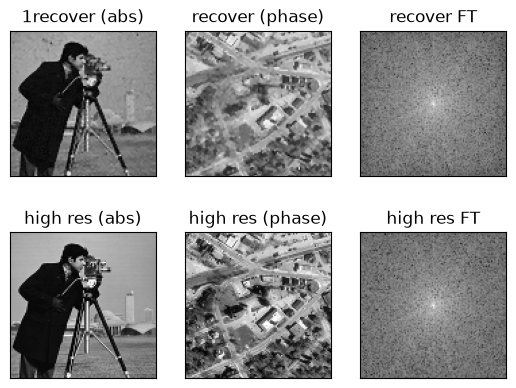

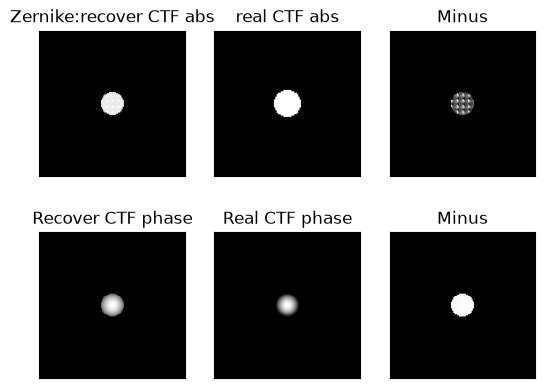

Show Image Sucess!


In [13]:
%matplotlib inline
show_result(fpm.OBJ, 1)

C:\Users\kennyzz\AppData\Local\Temp\ipykernel_28688\1092608059.py:151: UserWarning: Glyph 29289 (\N{CJK UNIFIED IDEOGRAPH-7269}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\kennyzz\AppData\Local\Temp\ipykernel_28688\1092608059.py:151: UserWarning: Glyph 20307 (\N{CJK UNIFIED IDEOGRAPH-4F53}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\kennyzz\AppData\Local\Temp\ipykernel_28688\1092608059.py:151: UserWarning: Glyph 24133 (\N{CJK UNIFIED IDEOGRAPH-5E45}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\kennyzz\AppData\Local\Temp\ipykernel_28688\1092608059.py:151: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\kennyzz\AppData\Local\Temp\ipykernel_28688\1092608059.py:151: UserWarning: Glyph 30456 (\N{CJK UNIFIED IDEOGRAPH-76F8}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\kennyzz\App

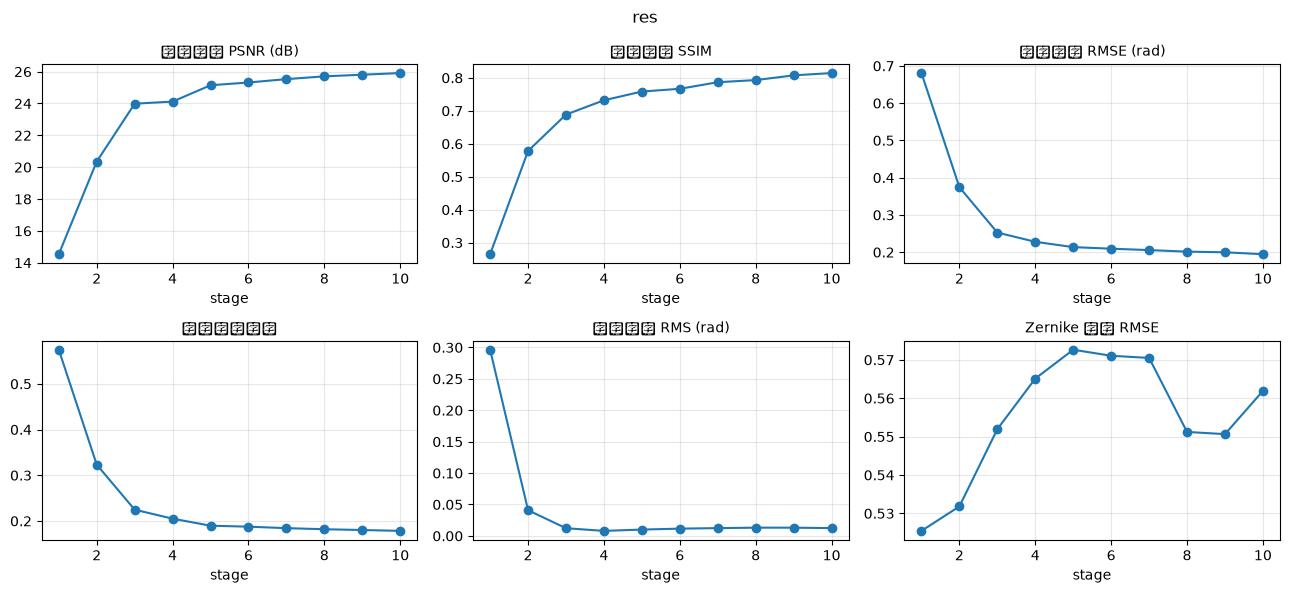

指标                             最终值
psnr_o_amp                 25.9110
ssim_o_amp                  0.8145
psnr_o_phi                 24.5374
ssim_o_phi                  0.8589
rmse_o_phi_rad              0.1946
relerr_o_complex            0.1783
rms_c_phi_rad               0.0124
rmse_c_zernike              0.5619


In [14]:
# [MIGRATED] 新增：定量指标曲线与汇总
plot_records(record_obj, record_ctf, title=run_name)
print_records(record_obj, record_ctf)

In [15]:
# [MIGRATED] 新增：消融实验对比工具
#
# 用法：分别保留每次训练返回的 record_obj，再直接比较这些内存记录。
#
#   baseline_record = record_obj
#   no_tv_record = record_obj
#   只留幅值 TV： tv1=1e-2, tv2=0
#   只留相位 TV： tv1=0,    tv2=1
#
# train() 开头会把 Or/Oi/Pr/Pi 四个权重全部重新初始化，模型里也只有这 4 个权重张量，
# 所以直接改参数重跑本 cell 即可，不需要重启内核、也不需要重新 fpm = FPM()。

def compare_runs(records, labels=None):
    """对比多个内存中的 object evaluation record。"""
    labels = labels or [f'run {i+1}' for i in range(len(records))]
    keys = ['psnr_o_amp','ssim_o_amp','rmse_o_phi_rad','relerr_o_complex']
    names = ['幅值PSNR(dB)','幅值SSIM','相位RMSE(rad)','复场相对误差']
    rows = []
    for d in records:
        rows.append([float(np.asarray(d[k]).ravel()[-1]) if k in d and np.asarray(d[k]).size else float('nan')
                     for k in keys])
    if not rows: return
    print(f"{'配置':<14s}" + ''.join(f'{n:>16s}' for n in names))
    for lab, r in zip(labels, rows):
        print(f'{lab:<14s}' + ''.join(f'{v:16.4f}' for v in r))

    plt.figure(figsize=(13,3.2))
    for i,(k,n) in enumerate(zip(keys,names)):
        plt.subplot(1,4,i+1)
        for d,lab in zip(records,labels):
            v = np.asarray(d[k]).ravel()
            if v.size: plt.plot(range(1,len(v)+1), v, 'o-', label=lab)
        plt.title(n, fontsize=10); plt.xlabel('stage'); plt.grid(alpha=.3); plt.legend(fontsize=8)
    plt.tight_layout(); plt.show()

# compare_runs([baseline_record, no_tv_record], ['TV', 'No TV'])